```mermaid
flowchart TD
    A[FairMOT idea] --> B[Shared encoder decoder]
    B --> C[Classification\nforeground heatmap]
    B --> D[Detection\noffset plus size]
    B --> E[Re identification\n128 dimensional embedding]
    C --> F[One center per cow]
    D --> F
    E --> F
    F --> G[Per frame evaluation\nnot online tracking]
```

```mermaid
flowchart LR
    A[mmCows] --> B[One cow class]
    A --> C[16 known identities]
    B --> D[Classification and detection]
    C --> E[Closed set re identification]
    D --> F[Three named heads]
    E --> F
```

```mermaid
flowchart TD
    A[Anchor based boxes] --> B[Overlapping or ambiguous identity features]
    C[Anchor free center] --> D[One feature per object]
    D --> E[Cleaner joint detection plus re identification]
```


```mermaid
flowchart LR
    A[mmCows visual frames] --> B[Four cameras]
    B --> C[YOLO labels: identity center width height]
    C --> D[Stride sampling]
    D --> E[Drop empty frames]
    E --> F[Resize 4480 by 2800 to 640 by 400]
    F --> G[Train and validation pools]
```

```mermaid
flowchart TD
    A[Identity ids 1 to 16] --> B[Training class ids 0 to 15]
    A --> C[Same identities may appear in validation]
    C --> D[Validation is never used for weight updates]
```


In [12]:
import torch

from n10_funs.config import (
    DEVICE, DATASET_NAME, DATA_ROOT, IMAGE_ROOT, LABEL_ROOT, CAMERAS,
    N_CLASSES, N_IDENTITIES, FRAME_STRIDE, MAX_SAMPLES, IMG_W, IMG_H, STRIDE,
    FEAT_W, FEAT_H, BATCH, check_dataset,
)

check_dataset()
print(f"{DATASET_NAME}: cameras={', '.join(CAMERAS)}")
print(DEVICE)


mmCows: cameras=cam_1, cam_2, cam_3, cam_4
cuda


In [13]:
import random

from n10_funs.loading_related_funs import load_frame_index

ALL_SAMPLES = load_frame_index()
if not ALL_SAMPLES:
    raise RuntimeError(f"No readable labelled {DATASET_NAME} frames found under {DATA_ROOT}")
random.shuffle(ALL_SAMPLES)
print(f"total samples: {len(ALL_SAMPLES)}")
print(f"out of {len(ALL_SAMPLES)} samples, {len(ALL_SAMPLES) / len(CAMERAS):.1f} per camera")


cam_1: 1589 usable frames
cam_2: 1588 usable frames
cam_3: 1589 usable frames
cam_4: 1589 usable frames
total samples: 6355
out of 6355 samples, 1588.8 per camera


In [14]:
from torch.utils.data import DataLoader

from n10_funs.loading_related_funs import split_samples
from n10_funs.dataset import MmCowsJointDataset, collate_joint

TRAIN_SAMPLES, VAL_SAMPLES = split_samples(ALL_SAMPLES, MAX_SAMPLES)

n_boxes_total = sum(len(b) for _, b in ALL_SAMPLES)
limit_text = "all" if MAX_SAMPLES is None else str(MAX_SAMPLES)
print(f"frames: {len(ALL_SAMPLES)} loaded (limit={limit_text}) -> {len(TRAIN_SAMPLES)} train / {len(VAL_SAMPLES)} val")
print(f"boxes:  {n_boxes_total} total, {n_boxes_total / len(ALL_SAMPLES):.1f} per frame")

train_loader = DataLoader(MmCowsJointDataset(TRAIN_SAMPLES), batch_size=BATCH, shuffle=True,
                           collate_fn=collate_joint, num_workers=0)
val_loader = DataLoader(MmCowsJointDataset(VAL_SAMPLES), batch_size=BATCH, shuffle=False,
                         collate_fn=collate_joint, num_workers=0)

x0, hm0, off0, sz0, ctr0, id0, mask0 = next(iter(train_loader))
print("image batch:", x0.shape, " heatmap:", hm0.shape, " boxes/frame (padded):", off0.shape[1])


frames: 6355 loaded (limit=500) -> 425 train / 75 val
boxes:  71229 total, 11.2 per frame
image batch: torch.Size([8, 3, 400, 640])  heatmap: torch.Size([8, 100, 160])  boxes/frame (padded): 13


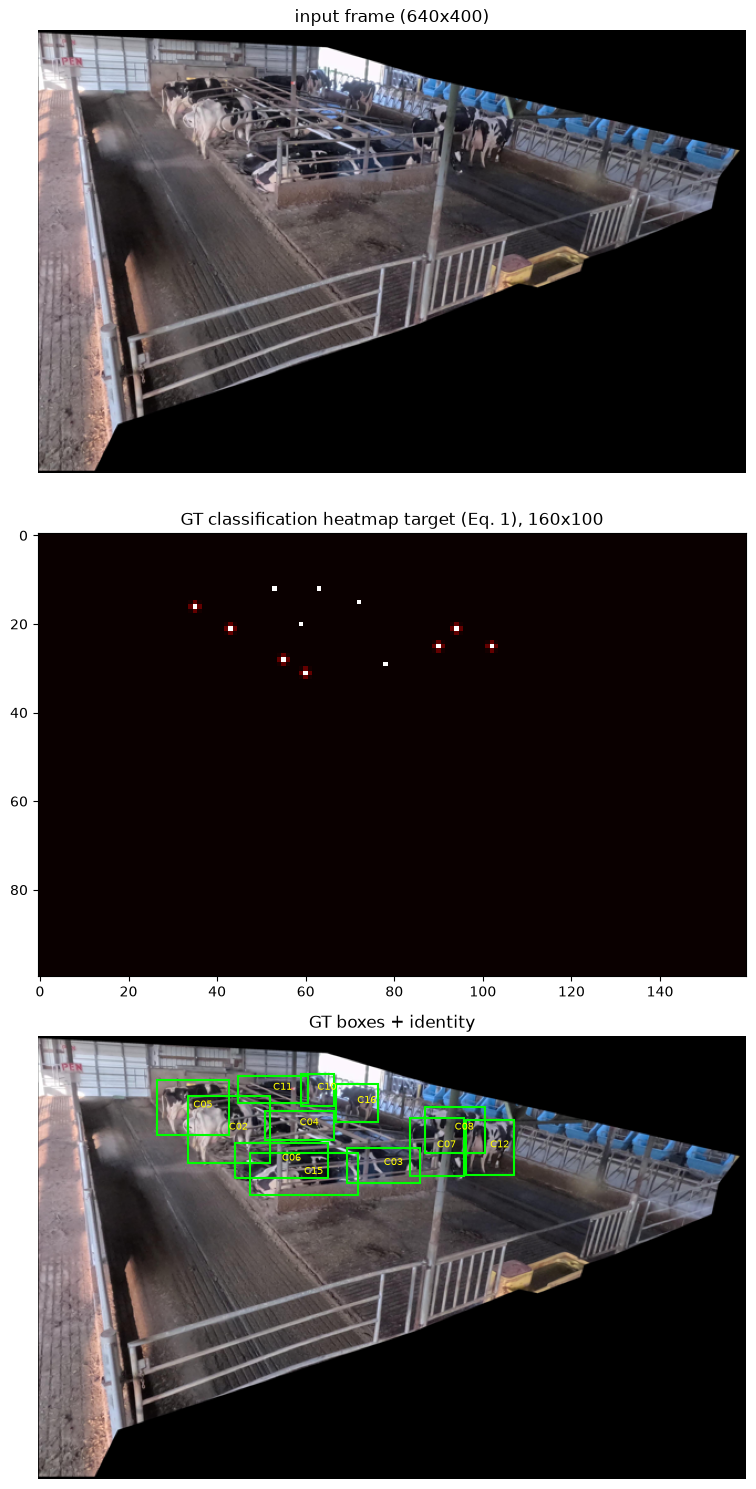

In [15]:
from n10_funs.viz import plot_batch_targets

plot_batch_targets(x0, hm0, ctr0, sz0, id0, STRIDE)


```mermaid
flowchart LR
    A[Data frame] --> B[Parse labels]
    B --> C[Build heatmap]
    B --> D[Build offset and size targets]
    B --> E[Build identity targets]
    C --> F[Batch collate]
    D --> F
    E --> F
    F --> G[Model input]
```


In [16]:
from n10_funs.model import count_params, show_shapes
from n10_funs.decode import decode_detections, box_iou


```mermaid
flowchart TD
    A[Input image] --> B[Shared encoder decoder\nfeature map at stride 4]
    B --> C[Classification head\nforeground score]
    B --> D[Detection head\noffset and box size]
    B --> E[Re identification head\nembedding map]
    C --> F[Center peaks]
    D --> G[Decoded boxes]
    E --> H[Identity logits]
    F --> G
    F --> H
```

```mermaid
flowchart LR
    A[Paper DLA 34 plus deformable conv] -. simplified .-> B[Small ResNet style encoder plus plain conv fusion]
    B --> C[Notebook friendly]
    B --> D[Accuracy gap is not a bug by itself]
```


In [17]:
from n10_funs.model import JointDetReIDModel

model = JointDetReIDModel().to(DEVICE)
print("trainable parameters:", f"{count_params(model):,}")
show_shapes(model)


trainable parameters: 1,736,632
classification (1, 1, 100, 160)
offset     (1, 2, 100, 160)
size       (1, 2, 100, 160)
reid_map   (1, 128, 100, 160)


```mermaid
flowchart LR
    A[Three outputs] --> B[Classification focal loss]
    A --> C[Detection offset plus size loss]
    A --> D[Re identification cross entropy]
    B --> E[Learned task weighting]
    C --> E
    D --> E
    E --> F[Joint loss]
```


In [18]:
from n10_funs.losses import focal_classification_loss, detection_l1_loss, joint_loss


```mermaid
flowchart TD
    A[Training setup] --> B[Adam learning rate 1e-4]
    B --> C[Forward pass]
    C --> D[Joint loss]
    D --> E[Backpropagation]
    E --> F[Update model and task weights]
    F --> G[Validation metrics]
    G --> H[History CSV]
```


In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # paper's own optimizer + starting LR (Sec. 5.2)

x, hm, off, sz, ctr, ids, mask = next(iter(train_loader))
x, hm = x.to(DEVICE), hm.to(DEVICE)
off, sz, ctr = off.to(DEVICE), sz.to(DEVICE), ctr.to(DEVICE)
ids, mask = ids.to(DEVICE), mask.to(DEVICE)

model.train()
outputs = model(x)
loss, parts = joint_loss(model, outputs, hm, off, sz, ctr, ids, mask)
print("loss components before any training:", parts)

optimizer.zero_grad()
loss.backward()
optimizer.step()
print("\nsingle step ran cleanly -- gradients flowed through all 3 heads and log_vars.")


loss components before any training: {'classification': 218.5165557861328, 'off': 0.41285133361816406, 'size': 1.2808867692947388, 'identity': 2.794666290283203, 'total': 74.33499145507812, 'w1': 0.0, 'w2': 0.0, 'w3': 0.0}

single step ran cleanly -- gradients flowed through all 3 heads and log_vars.


```mermaid
flowchart LR
    A[Epoch] --> B[Train loss]
    B --> C[Classification loss]
    B --> D[Detection loss]
    B --> E[Re identification loss]
    A --> F[Train accuracy]
    A --> G[Validation accuracy]
    A --> H[Learning rate]
```


In [20]:
from n10_funs.train import fit, evaluate_identity_head


In [ ]:
model = JointDetReIDModel().to(DEVICE)   # fresh model
history = fit(model, train_loader, val_loader, epochs=30, lr=1e-4)
# save model and history
from n10_funs.checkpoint import RUN_DIR
RUN_DIR.mkdir(parents=True, exist_ok=True)

epoch   1/30  | total   46.882 | cls  136.421 | det    1.659 | re-id    2.769 | train_acc    6.9% | val_acc    9.9% | time    60.2s | lr 1.0e-04 | gpu    4858MB
epoch   2/30  | total    7.218 | cls   17.524 | det    1.502 | re-id    2.713 | train_acc   13.1% | val_acc   13.2% | time    56.6s | lr 1.0e-04 | gpu    1055MB
epoch   3/30  | total    3.327 | cls    6.041 | det    1.338 | re-id    2.651 | train_acc   13.1% | val_acc   13.2% | time    56.7s | lr 1.0e-04 | gpu    1053MB
epoch   4/30  | total    2.523 | cls    3.842 | det    1.154 | re-id    2.617 | train_acc   13.8% | val_acc   14.2% | time    56.1s | lr 1.0e-04 | gpu    1054MB
epoch   5/30  | total    2.178 | cls    3.038 | det    0.949 | re-id    2.595 | train_acc   14.6% | val_acc   16.1% | time    56.9s | lr 1.0e-04 | gpu    1054MB
epoch   6/30  | total    1.968 | cls    2.611 | det    0.791 | re-id    2.550 | train_acc   16.6% | val_acc   19.0% | time    59.1s | lr 1.0e-04 | gpu    1054MB
epoch   7/30  | total    1.831 | c

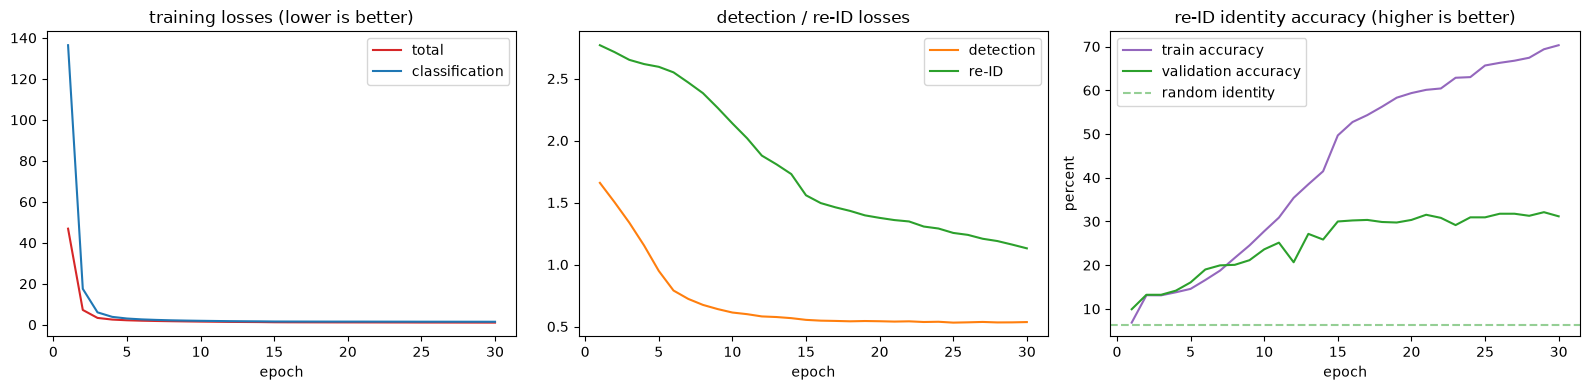


Final learned task weights (log_vars, Eq. 5 reorganized into 3 terms): [0.006516863126307726, -0.04118013009428978, 0.06321579962968826]
A more negative w_i means that task's loss is trusted/weighted more heavily.
A large positive w_i means the network has learned to downweight a noisy or hard task.


In [22]:
from n10_funs.viz import plot_history
# import history model
plot_history(history)
print("\nFinal learned task weights (log_vars, Eq. 5 reorganized into 3 terms):",
      model.log_vars.detach().cpu().tolist())
print("A more negative w_i means that task's loss is trusted/weighted more heavily.")
print("A large positive w_i means the network has learned to downweight a noisy or hard task.")


```mermaid
flowchart TD
    A[Validation frames] --> B[Decode center peaks]
    B --> C[Classification plus detection]
    C --> D[IoU matching]
    D --> E[Precision and recall]
    A --> F[Re identification at GT centers]
    F --> G[Closed set identity accuracy]
```


In [23]:
from n10_funs.train import evaluate_detection

precision, recall, tp, fp, fn = evaluate_detection(model, val_loader)
id_acc = evaluate_identity_head(model, val_loader)
print(f"Classification+Detection (IoU>=0.5): precision={precision:.2%}  recall={recall:.2%}  (tp={tp}, fp={fp}, fn={fn})")
print(f"Identity accuracy (closed-set, 16 known cows): {id_acc:.1f}%  (random guess: {100/N_IDENTITIES:.1f}%)")


Classification+Detection (IoU>=0.5): precision=60.40%  recall=7.20%  (tp=61, fp=40, fn=786)
Identity accuracy (closed-set, 16 known cows): 31.2%  (random guess: 6.2%)


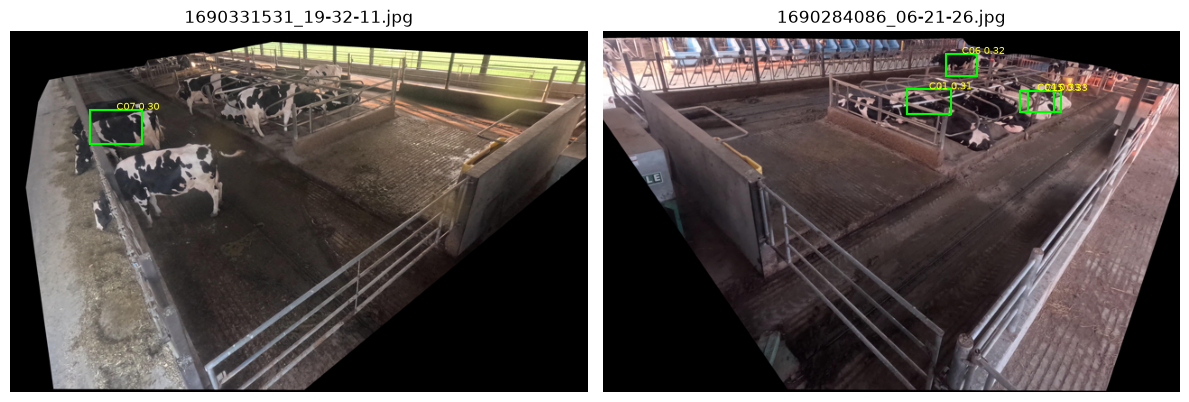

In [32]:
from n10_funs.viz import predict_and_draw

predict_and_draw(model, VAL_SAMPLES, n_show=2)


```mermaid
flowchart TD
    A[Anchor free] --> B[Center plus size]
    C[Heatmap] --> D[Foreground confidence]
    E[Gaussian radius] --> F[Stable center target]
    G[Uncertainty weighting] --> H[Learned task balance]
    I[Closed set re identification] --> J[Known cow classifier]
    K[Feature fusion] --> L[Fine spatial plus deep semantic features]
```


```mermaid
flowchart TD
    A[Baseline run] --> B[Change one setting]
    B --> C[Train again]
    C --> D[Compare losses and metrics]
    D --> E[Keep or revert the change]
    B --> F[Uncertainty weighting]
    B --> G[Geometric augmentation]
    B --> H[Deformable convolution]
    B --> I[Embedding dimension]
    B --> J[Online association]
    B --> K[Held out camera]
```


```mermaid
flowchart LR
    A[Trained model] --> B[Atomic checkpoint write]
    B --> C[model.pt]
    A --> D[History]
    D --> E[history.csv]
    A --> F[Configuration]
    F --> G[config.json inside checkpoint]
```


In [25]:
from n10_funs.checkpoint import save_checkpoint

save_checkpoint(model, history)


saved and verified mmCows model + history to runs\n10_joint_det_reid\model.pt


WindowsPath('runs/n10_joint_det_reid/model.pt')